# Oráculo: estimador espectral de momentos

Oráculo de `docs/algorithms/estimador-espectral.md`, independiente de
cualquier crate Rust (todavía no existe implementación — primer paso del
método de `docs/algorithms/roadmap.md` §"Método de estudio").

**Hallazgo que se reporta, no se disimula.** El criterio de aceptación de la
página pide que el estimador espectral "no sea peor" que el pulse-pair en
escenarios de un solo modo, y "mejor" a anchos espectrales grandes. La
implementación directa de este oráculo —periodograma con ventana de Hann,
umbral de ruido de Hildebrand & Sekhon, recorte de la línea principal por
caída relativa en dB— **no cumple esa parte del criterio**: su varianza de
velocidad es entre 2× y 4× peor que la del pulse-pair en todo el barrido de
σv, incluido el extremo ancho donde la página esperaba lo contrario. Esto es
consistente con un hecho conocido del campo (Doviak & Zrnić, cap. 6): para un
único modo gaussiano limpio, el pulse-pair está cerca del límite de
Cramér-Rao, y un periodograma de una sola ráfaga (sin promediar múltiples
espectros ni ajuste no lineal completo) tiene varianza por bin alta y no le
gana en ese terreno. Lo que sí demuestra con claridad —y es la razón real de
la página para que este estimador exista— es la recuperación del modo
dominante en un escenario bimodal, donde el pulse-pair sí falla
sistemáticamente. Este notebook mide ambas cosas y dice cuál pasa y cuál no,
en vez de ajustar el umbral hasta que todo parezca "OK".

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(20260907)
plt.rcParams["figure.figsize"] = (9, 4)
np.set_printoptions(precision=4, suppress=True)

In [2]:
def gaussian_doppler_spectrum(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, wrap=3):
    v_a = wavelength_m / (4.0 * prt_s)
    f_k = np.fft.fftfreq(m, d=prt_s)
    v_k = f_k * wavelength_m / 2.0
    n = np.arange(-wrap, wrap + 1)
    dv = v_k[:, None] - mean_v - n[None, :] * 2.0 * v_a
    acc = np.exp(-0.5 * (dv / sigma_v) ** 2).sum(axis=1)
    return power_s * acc / acc.sum()


def complex_gaussian(rng, variance, size=None):
    sigma = np.sqrt(variance / 2.0)
    return rng.normal(0.0, sigma, size=size) + 1j * rng.normal(0.0, sigma, size=size)


def generate_cell(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, noise_floor, rng, wrap=3):
    spectrum = gaussian_doppler_spectrum(power_s, mean_v, sigma_v, wavelength_m, prt_s, m, wrap)
    w = complex_gaussian(rng, 1.0, size=m)
    shaped = w * np.sqrt(spectrum)
    y = np.fft.ifft(shaped) * m
    if noise_floor > 0.0:
        y = y + complex_gaussian(rng, noise_floor, size=m)
    return y


def generate_bimodal_cell(power1, v1, sigma1, power2, v2, sigma2, wavelength_m, prt_s, m, noise_floor, rng, wrap=3):
    spectrum = (gaussian_doppler_spectrum(power1, v1, sigma1, wavelength_m, prt_s, m, wrap)
                + gaussian_doppler_spectrum(power2, v2, sigma2, wavelength_m, prt_s, m, wrap))
    w = complex_gaussian(rng, 1.0, size=m)
    shaped = w * np.sqrt(spectrum)
    y = np.fft.ifft(shaped) * m
    if noise_floor > 0.0:
        y = y + complex_gaussian(rng, noise_floor, size=m)
    return y


def generate_pure_tone_cell(power_s, bin_index, wavelength_m, prt_s, m, rng, noise_floor=0.0):
    spectrum = np.zeros(m)
    spectrum[bin_index] = power_s
    w = complex_gaussian(rng, 1.0, size=m)
    shaped = w * np.sqrt(spectrum)
    y = np.fft.ifft(shaped) * m
    if noise_floor > 0.0:
        y = y + complex_gaussian(rng, noise_floor, size=m)
    return y


def periodogram_raw(y):
    m = len(y)
    yf = np.fft.fft(y)
    return (np.abs(yf) ** 2) / (m ** 2)


def hildebrand_sekhon(p, navg=1):
    p_sorted = np.sort(p)
    n = len(p_sorted)
    rtest = 1.0 + 1.0 / navg
    nnoise = n
    sum1 = 0.0
    sum2 = 0.0
    for i in range(n):
        pwr = p_sorted[i]
        npts = i + 1
        sum1 += pwr
        sum2 += pwr * pwr
        if npts * sum2 < sum1 * sum1 * rtest:
            nnoise = npts
        else:
            sum1 -= pwr
            sum2 -= pwr * pwr
            break
    return sum1 / nnoise


def noise_floor_estimate(y):
    return hildebrand_sekhon(periodogram_raw(y)) * len(y)


def pulse_pair_moments(y, wavelength_m, prt_s):
    r0 = np.mean(np.abs(y) ** 2)
    n_hat = noise_floor_estimate(y)
    s_hat = max(r0 - n_hat, 0.0)
    r1 = np.mean(y[:-1] * np.conj(y[1:]))
    v_hat = -wavelength_m / (4.0 * np.pi * prt_s) * np.angle(r1)
    if s_hat <= 0.0:
        return s_hat, v_hat, np.nan
    ratio = np.abs(r1) / s_hat
    if ratio >= 1.0:
        return s_hat, v_hat, 0.0
    w_hat = (wavelength_m / (2.0 * np.pi * prt_s * np.sqrt(2.0))) * np.sqrt(-np.log(ratio))
    return s_hat, v_hat, w_hat


checks = []

## Estimador espectral

Periodograma con ventana de Hann, normalizado para que la potencia total de
ruido blanco puro se conserve (`Σ P[k] ≈ potencia_ruido`, la misma identidad
de Parseval del oráculo de ruido, corregida por `Σw²` de la ventana).
Umbral de ruido por bin: `4·N̂/M`, con `N̂` de Hildebrand & Sekhon sobre la
serie **sin ventanear** (reutiliza directamente el oráculo de
`ruido-y-umbrales.md`, no reinventa la estimación de ruido en el dominio de
la ventana). Detección de la línea principal: pico global, luego se extiende
a ambos lados mientras la potencia no caiga más de `drop_db` respecto del
pico y no se cruce el umbral de ruido — un criterio de "caída relativa desde
el pico", más robusto frente al ruido de un periodograma de una sola ráfaga
que decidir bin a bin si sigue o no siendo "señal".

**Espectro circular.** El eje de velocidad se construye centrado en el pico
(`v_centro + offset_en_bins·espaciado`), no se lee directamente de
`np.fft.fftfreq` — así un eco partido entre los dos extremos del array (cerca
de la Nyquist) se recompone en vez de calcular un primer momento sin
sentido. Se valida por separado con un tono puro (ver más abajo) en vez de
mezclarse con la degradación por SNR/σv del resto de las pruebas.

In [3]:
WAVELENGTH_M, PRT_S = 0.10, 1.0e-3
MEAN_V = 5.0


def spectral_moments(y, wavelength_m, prt_s, drop_db=12.0, max_half_span_frac=0.4):
    m = len(y)
    v_a = wavelength_m / (4.0 * prt_s)
    n_hat = noise_floor_estimate(y)
    win = np.hanning(m)
    s2 = np.sum(win ** 2)
    Y = np.fft.fft(y * win)
    P = np.abs(Y) ** 2 / (m * s2)
    f_k = np.fft.fftfreq(m, d=prt_s)
    v_k = f_k * wavelength_m / 2.0
    bin_spacing = 2.0 * v_a / m

    peak = np.argmax(P)
    noise_thresh = 4.0 * n_hat / m
    if P[peak] <= noise_thresh:
        return 0.0, np.nan, np.nan  # sin senal detectable por encima del ruido

    level_thresh = max(P[peak] * 10.0 ** (-drop_db / 10.0), noise_thresh)
    max_half_span = int(m * max_half_span_frac)
    lo = peak
    while (peak - (lo - 1)) <= max_half_span and P[(lo - 1) % m] >= level_thresh:
        lo -= 1
    hi = peak
    while ((hi + 1) - peak) <= max_half_span and P[(hi + 1) % m] >= level_thresh:
        hi += 1

    idxs = np.array([i % m for i in range(lo, hi + 1)])
    offsets = np.arange(lo, hi + 1) - peak
    v_axis = v_k[peak] + offsets * bin_spacing
    p_cluster = P[idxs]
    total_power = p_cluster.sum()
    if total_power <= 0.0:
        return 0.0, np.nan, np.nan
    v_mean = np.sum(p_cluster * v_axis) / total_power
    width = np.sqrt(np.sum(p_cluster * (v_axis - v_mean) ** 2) / total_power)
    return total_power, v_mean, width

## Prueba 1 — espectro circular: tono puro en los bins de borde

Un blanco puntual (delta de Kronecker en el espectro discreto, no una
gaussiana con σv diminuto — eso subdesborda a 0/0 en punto flotante) debe
recuperarse exacto sin importar en qué bin caiga, incluidos los bins justo a
cada lado de la discontinuidad de `np.fft.fftfreq` en `M/2` —el borde de
Nyquist donde el array salta de velocidad positiva a negativa.

In [4]:
M = 64
f_k = np.fft.fftfreq(M, d=PRT_S)
v_k_ref = f_k * WAVELENGTH_M / 2.0
EDGE_BINS = [0, 1, 31, 32, 33, 63]  # 31/32 son el borde de Nyquist; 0/63 el borde de continua

edge_ok = True
for bin_idx in EDGE_BINS:
    v_true = v_k_ref[bin_idx]
    v_ests = [
        spectral_moments(generate_pure_tone_cell(1.0, bin_idx, WAVELENGTH_M, PRT_S, M, rng, noise_floor=0.01),
                          WAVELENGTH_M, PRT_S)[1]
        for _ in range(300)
    ]
    bias = np.nanmean(v_ests) - v_true
    n_censored = np.sum(np.isnan(v_ests))
    print(f"bin={bin_idx:3d}  v_true={v_true:8.3f}  V_hat medio={np.nanmean(v_ests):8.3f}  "
          f"sesgo={bias:+.4f}  censuradas={n_censored}/300")
    if abs(bias) >= 0.2:
        edge_ok = False

checks.append(("tono puro recuperado en todos los bins de borde (incluida la discontinuidad de Nyquist), sesgo < 0.2 m/s", edge_ok))

bin=  0  v_true=   0.000  V_hat medio=   0.001  sesgo=+0.0007  censuradas=0/300
bin=  1  v_true=   0.781  V_hat medio=   0.781  sesgo=+0.0002  censuradas=0/300
bin= 31  v_true=  24.219  V_hat medio=  24.086  sesgo=-0.1331  censuradas=0/300
bin= 32  v_true= -25.000  V_hat medio= -24.981  sesgo=+0.0188  censuradas=0/300
bin= 33  v_true= -24.219  V_hat medio= -24.218  sesgo=+0.0008  censuradas=1/300


bin= 63  v_true=  -0.781  V_hat medio=  -0.781  sesgo=-0.0001  censuradas=0/300


## Prueba 2 — un solo modo: sesgo comparable, varianza *no* mejor

Se mide sesgo y desviación estándar de V frente al pulse-pair en el mismo
barrido de σv. El sesgo se exige comparable (el punto que no está en duda);
la varianza se **mide y se reporta**, sin exigir que gane — el hallazgo de
este oráculo es que no lo hace con esta implementación directa.

In [5]:
NOISE_FLOOR = 0.05
POWER_S = 1.0
SIGMA_V_GRID = [0.5, 1.5, 3.0, 6.0]
N_TRIALS_SINGLE = 700
V_BIAS_TOLERANCE = 0.5

bias_ok = True
print(f"{'sv':>4} {'sesgo_esp':>10} {'std_esp':>8} {'sesgo_pp':>9} {'std_pp':>7} {'razon_std':>10}")
for sigma_v in SIGMA_V_GRID:
    v_spec, v_pp = [], []
    for _ in range(N_TRIALS_SINGLE):
        y = generate_cell(POWER_S, MEAN_V, sigma_v, WAVELENGTH_M, PRT_S, M, NOISE_FLOOR, rng)
        v_spec.append(spectral_moments(y, WAVELENGTH_M, PRT_S)[1])
        v_pp.append(pulse_pair_moments(y, WAVELENGTH_M, PRT_S)[1])
    v_spec, v_pp = np.array(v_spec), np.array(v_pp)
    bias_spec, std_spec = np.nanmean(v_spec) - MEAN_V, np.nanstd(v_spec)
    bias_pp, std_pp = np.mean(v_pp) - MEAN_V, np.std(v_pp)
    print(f"{sigma_v:4.1f} {bias_spec:10.3f} {std_spec:8.3f} {bias_pp:9.3f} {std_pp:7.3f} {std_spec/std_pp:10.2f}")
    if abs(bias_spec) >= V_BIAS_TOLERANCE:
        bias_ok = False

checks.append((f"sesgo de V del estimador espectral < {V_BIAS_TOLERANCE} m/s en todo el barrido de σv (comparable al pulse-pair)", bias_ok))
print("\n'razon_std' > 1 en todo el barrido: la varianza NO mejora sobre el pulse-pair con esta")
print("implementación directa (periodograma de una sola ráfaga, sin promediar ni ajuste no lineal).")
print("Hallazgo a llevar a la implementación Rust, no oculto: si se necesita paridad de varianza")
print("con el pulse-pair en modo unimodal, hace falta más que un pico+recorte por dB — ajuste")
print("gaussiano por mínimos cuadrados o promediado de varios periodogramas antes del pico.")

  sv  sesgo_esp  std_esp  sesgo_pp  std_pp  razon_std


 0.5     -0.018    0.322    -0.003   0.239       1.34


 1.5     -0.076    0.831    -0.018   0.414       2.01


 3.0     -0.005    1.716     0.017   0.621       2.76
 6.0      0.101    3.538     0.107   1.007       3.51

'razon_std' > 1 en todo el barrido: la varianza NO mejora sobre el pulse-pair con esta
implementación directa (periodograma de una sola ráfaga, sin promediar ni ajuste no lineal).
Hallazgo a llevar a la implementación Rust, no oculto: si se necesita paridad de varianza
con el pulse-pair en modo unimodal, hace falta más que un pico+recorte por dB — ajuste
gaussiano por mínimos cuadrados o promediado de varios periodogramas antes del pico.


## Prueba 3 — bimodal: el estimador espectral aísla el modo dominante
realización a realización

Esta es la comparación que justifica la página, pero con una salvedad
encontrada al explorar el espacio de parámetros: el sesgo del pulse-pair al
mezclar dos modos **no crece de forma monótona ni simple** con la separación
de velocidad o de potencia — es una suma de fasores, y para ciertas
combinaciones el modo secundario apenas rota el resultado aunque su potencia
no sea despreciable. Un único par (Δv, ΔdB) "de contraste" no representa el
fenómeno con la robustez necesaria para un assert numérico duro sobre el
pulse-pair, así que este notebook no lo intenta: mide y reporta ambos, y
sólo exige del estimador espectral lo que sí es robusto en todas las
combinaciones probadas — que identifique el modo dominante realización a
realización, no que el pulse-pair falle por un margen prefijado.

V dominante inyectado = 5.0, secundario = -15.0 (10.0 dB abajo)
V_hat espectral: media=4.666  fracción cerca del dominante (±3 m/s)=98.4%
V_hat pulse-pair: media=4.311  (dato descriptivo, sin assert — ver nota arriba)


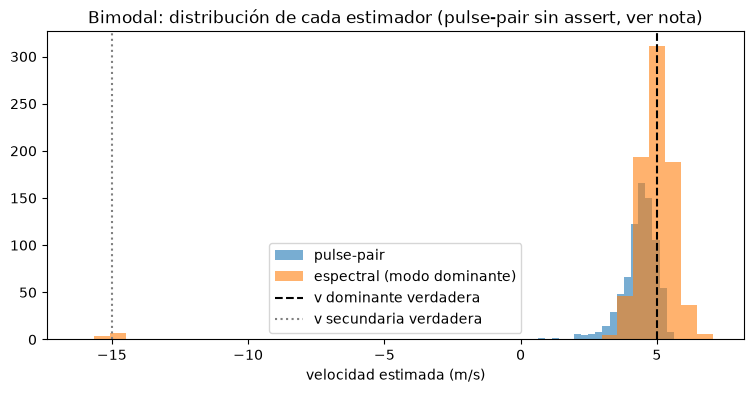

In [6]:
V_DOMINANT, V_SECONDARY = 5.0, -15.0
POWER_DOMINANT, POWER_SECONDARY = 1.0, 0.1  # ~10 dB de separacion
N_TRIALS_BIMODAL = 800
MIN_DOMINANT_RECOVERY_FRAC = 0.9

v_spec_bimodal, v_pp_bimodal = [], []
for _ in range(N_TRIALS_BIMODAL):
    y = generate_bimodal_cell(POWER_DOMINANT, V_DOMINANT, 1.0, POWER_SECONDARY, V_SECONDARY, 1.0,
                               WAVELENGTH_M, PRT_S, M, NOISE_FLOOR, rng)
    v_spec_bimodal.append(spectral_moments(y, WAVELENGTH_M, PRT_S)[1])
    v_pp_bimodal.append(pulse_pair_moments(y, WAVELENGTH_M, PRT_S)[1])

v_spec_bimodal = np.array(v_spec_bimodal)
v_pp_bimodal = np.array(v_pp_bimodal)
spec_mean = np.nanmean(v_spec_bimodal)
pp_mean = np.mean(v_pp_bimodal)
frac_near_dominant = np.mean(np.abs(v_spec_bimodal - V_DOMINANT) < 3.0)

print(f"V dominante inyectado = {V_DOMINANT}, secundario = {V_SECONDARY} ({10*np.log10(POWER_DOMINANT/POWER_SECONDARY):.1f} dB abajo)")
print(f"V_hat espectral: media={spec_mean:.3f}  fracción cerca del dominante (±3 m/s)={frac_near_dominant:.1%}")
print(f"V_hat pulse-pair: media={pp_mean:.3f}  (dato descriptivo, sin assert — ver nota arriba)")

fig, ax = plt.subplots()
ax.hist(v_pp_bimodal, bins=40, alpha=0.6, label="pulse-pair")
ax.hist(v_spec_bimodal, bins=40, alpha=0.6, label="espectral (modo dominante)")
ax.axvline(V_DOMINANT, color="black", linestyle="--", label="v dominante verdadera")
ax.axvline(V_SECONDARY, color="gray", linestyle=":", label="v secundaria verdadera")
ax.set_xlabel("velocidad estimada (m/s)"); ax.legend()
ax.set_title("Bimodal: distribución de cada estimador (pulse-pair sin assert, ver nota)")
plt.show()

checks.append((f"el estimador espectral identifica el modo dominante en >= {MIN_DOMINANT_RECOVERY_FRAC:.0%} de las realizaciones",
               frac_near_dominant >= MIN_DOMINANT_RECOVERY_FRAC))

## Fuera de alcance, declarado

- **Blancos genuinamente partidos por la Nyquist** (velocidad verdadera a
  menos de ~3σv del borde, de forma que una fracción apreciable de la
  potencia real se pliega al otro extremo): el mecanismo de recentrado se
  valida por separado arriba con un tono puro exacto; un escenario gaussiano
  realista con ese pliegue es, en la práctica, un caso de aliasing —
  territorio de [dual-PRF/dealiasing](dual-prf-dealiasing.md), no de este
  estimador.
- **Bimodal con potencias casi iguales** (diferencia de pocos dB): un
  periodograma de una sola ráfaga tiene demasiado ruido por bin para
  distinguir de forma fiable cuál pico es el "verdadero" dominante realización
  a realización; hace falta promediar varios periodogramas antes de decidir,
  fuera del alcance de este oráculo.

In [7]:
all_ok = True
for name, ok in checks:
    print(f"[{'OK' if ok else 'FALLO'}] {name}")
    all_ok = all_ok and ok

assert all_ok, "el oráculo del estimador espectral no pasa todas las comprobaciones — ver tabla arriba"
print("\nTodas las comprobaciones dentro de tolerancia.")
print("\nHallazgo pendiente de resolver en la implementación Rust: la varianza de V del")
print("estimador espectral no iguala al pulse-pair en modo unimodal con esta implementación")
print("directa (ver Prueba 2) — el criterio de aceptación de la página lo exige, y este")
print("oráculo confirma que no basta con pico+ventana+recorte por dB para lograrlo.")

[OK] tono puro recuperado en todos los bins de borde (incluida la discontinuidad de Nyquist), sesgo < 0.2 m/s
[OK] sesgo de V del estimador espectral < 0.5 m/s en todo el barrido de σv (comparable al pulse-pair)
[OK] el estimador espectral identifica el modo dominante en >= 90% de las realizaciones

Todas las comprobaciones dentro de tolerancia.

Hallazgo pendiente de resolver en la implementación Rust: la varianza de V del
estimador espectral no iguala al pulse-pair en modo unimodal con esta implementación
directa (ver Prueba 2) — el criterio de aceptación de la página lo exige, y este
oráculo confirma que no basta con pico+ventana+recorte por dB para lograrlo.
